# REINFORCE Algorithm for CartPole-v1

## Exercise 1: Conceptual Questions

### 1. DQN vs. REINFORCE

**Fundamental difference in neural network outputs:**

- **DQN (Deep Q-Network)**: The neural network outputs **action values (Q-values)** - one scalar per action representing the expected cumulative reward for taking that action in the given state. The policy is implicitly defined by choosing the action with the highest Q-value (ε-greedy).

- **REINFORCE**: The neural network outputs a **probability distribution over actions** (via softmax). It directly represents the policy π(a|s) - the probability of taking each action in the given state. The network does not estimate values, but rather learns the optimal stochastic policy directly.

### 2. The Log-Probability Term

We use the logarithm because:

- **Derivative simplification**: ∇ log π(a|s) = ∇π(a|s) / π(a|s). This avoids directly computing the derivative of the product of probabilities.

- **Turning products into sums**: The probability of a trajectory is ∏ π(a_t|s_t). Taking the log turns this product into ∑ log π(a_t|s_t), making gradients additive across timesteps.

- **Numerical stability**: Log probabilities are more numerically stable when dealing with very small probabilities.

### 3. High Variance in REINFORCE

REINFORCE has high variance because:

- **Credit assignment problem**: A single action early in a long episode affects all subsequent rewards, but the algorithm uses the total return G_t (sum of all future rewards). If the episode ends badly, the early action gets "blamed" even if it was actually good.

- **Monte Carlo sampling**: REINFORCE uses complete episode returns, which can vary dramatically due to randomness in the environment and policy, not just the action's quality.

- **Delayed consequences**: An action might be good but lead to negative rewards much later due to unrelated events. REINFORCE cannot distinguish this correlation from causation.

In [1]:
# Install required packages
# !pip install torch gym matplotlib numpy

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Gym version: {gym.__version__}")

PyTorch version: 2.10.0+cpu
Gym version: 1.2.3


## Exercise 2: Implementing REINFORCE for CartPole

In [3]:
# Step 1: Set up the environment
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]  # 4
action_dim = env.action_space.n  # 2

print(f"State dimension: {state_dim}")
print(f"Action dimension: {action_dim}")

State dimension: 4
Action dimension: 2


In [4]:
# Step 2: Define the Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_dim)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=-1)
        return x

# Test the network
policy = PolicyNetwork(state_dim, action_dim)
test_state = torch.randn(1, state_dim)
test_probs = policy(test_state)
print(f"Test output probabilities: {test_probs.detach().numpy()}")
print(f"Sum of probabilities: {test_probs.sum().item():.4f}")

Test output probabilities: [[0.45410872 0.5458912 ]]
Sum of probabilities: 1.0000


In [5]:
# Step 3: Implement select_action function
def select_action(policy, state):
    """
    Select an action using the policy network.
    
    Args:
        policy: The policy network
        state: Current environment state
    
    Returns:
        action: The chosen action
        log_prob: Log probability of the chosen action
    """
    state = torch.from_numpy(state).float().unsqueeze(0)
    probs = policy(state)
    m = Categorical(probs)
    action = m.sample()
    log_prob = m.log_prob(action)
    return action.item(), log_prob

In [6]:
# Step 4: Implement the training loop for basic REINFORCE
def compute_returns(rewards, gamma=0.99):
    """
    Compute discounted returns G_t.
    
    Args:
        rewards: List of rewards from an episode
        gamma: Discount factor
    
    Returns:
        List of discounted returns
    """
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

def train_reinforce(env, policy, optimizer, num_episodes=1000, gamma=0.99, print_every=100):
    """
    Train the policy using basic REINFORCE algorithm.
    
    Returns:
        episode_rewards: List of total rewards per episode
    """
    episode_rewards = []
    
    for episode in range(num_episodes):
        state = env.reset()[0]  # Gym v26 returns (state, info)
        log_probs = []
        rewards = []
        
        # Play one episode
        while True:
            action, log_prob = select_action(policy, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            log_probs.append(log_prob)
            rewards.append(reward)
            
            if done:
                break
            state = next_state
        
        episode_rewards.append(sum(rewards))
        
        # Calculate returns
        returns = compute_returns(rewards, gamma)
        returns = torch.tensor(returns)
        
        # Normalize returns for better training
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)
        
        # Calculate loss
        loss = []
        for log_prob, G in zip(log_probs, returns):
            loss.append(-log_prob * G)
        loss = torch.cat(loss).sum()
        
        # Update policy
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Print progress
        if (episode + 1) % print_every == 0:
            recent_rewards = episode_rewards[-print_every:]
            avg_reward = np.mean(recent_rewards)
            print(f"Episode {episode + 1}: Average reward (last {print_every} episodes) = {avg_reward:.2f}")
    
    return episode_rewards

In [7]:
# Train basic REINFORCE
print("=" * 50)
print("Training Basic REINFORCE")
print("=" * 50)

policy_basic = PolicyNetwork(state_dim, action_dim)
optimizer_basic = optim.Adam(policy_basic.parameters(), lr=0.01)

rewards_basic = train_reinforce(env, policy_basic, optimizer_basic, num_episodes=1000, print_every=100)

Training Basic REINFORCE
Episode 100: Average reward (last 100 episodes) = 9.64
Episode 200: Average reward (last 100 episodes) = 9.34
Episode 300: Average reward (last 100 episodes) = 9.35
Episode 400: Average reward (last 100 episodes) = 9.37
Episode 500: Average reward (last 100 episodes) = 9.30
Episode 600: Average reward (last 100 episodes) = 9.37
Episode 700: Average reward (last 100 episodes) = 9.24
Episode 800: Average reward (last 100 episodes) = 9.34
Episode 900: Average reward (last 100 episodes) = 9.42
Episode 1000: Average reward (last 100 episodes) = 9.53


## Exercise 3: Challenge Problem - Adding a Baseline

In [8]:
def train_reinforce_with_baseline(env, policy, optimizer, num_episodes=1000, gamma=0.99, print_every=100):
    """
    Train the policy using REINFORCE with a baseline (running average of returns).
    
    Returns:
        episode_rewards: List of total rewards per episode
        baselines: List of baseline values per episode
    """
    episode_rewards = []
    baselines = []
    running_avg_return = 0
    alpha = 0.01  # Learning rate for running average
    
    for episode in range(num_episodes):
        state = env.reset()[0]
        log_probs = []
        rewards = []
        
        # Play one episode
        while True:
            action, log_prob = select_action(policy, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            log_probs.append(log_prob)
            rewards.append(reward)
            
            if done:
                break
            state = next_state
        
        episode_rewards.append(sum(rewards))
        
        # Calculate returns
        returns = compute_returns(rewards, gamma)
        returns_tensor = torch.tensor(returns)
        
        # Update running average baseline
        episode_return = sum(rewards)
        running_avg_return = running_avg_return * (1 - alpha) + episode_return * alpha
        baselines.append(running_avg_return)
        
        # Center returns by subtracting baseline
        centered_returns = returns_tensor - running_avg_return
        
        # Normalize for stability (optional but helpful)
        if len(centered_returns) > 1 and centered_returns.std() > 0:
            centered_returns = (centered_returns - centered_returns.mean()) / (centered_returns.std() + 1e-9)
        
        # Calculate loss with baseline
        loss = []
        for log_prob, G in zip(log_probs, centered_returns):
            loss.append(-log_prob * G)
        loss = torch.cat(loss).sum()
        
        # Update policy
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Print progress
        if (episode + 1) % print_every == 0:
            recent_rewards = episode_rewards[-print_every:]
            avg_reward = np.mean(recent_rewards)
            print(f"Episode {episode + 1}: Average reward (last {print_every} episodes) = {avg_reward:.2f}, Baseline = {running_avg_return:.2f}")
    
    return episode_rewards, baselines

In [9]:
# Train REINFORCE with baseline
print("\n" + "=" * 50)
print("Training REINFORCE with Baseline")
print("=" * 50)

policy_baseline = PolicyNetwork(state_dim, action_dim)
optimizer_baseline = optim.Adam(policy_baseline.parameters(), lr=0.01)

rewards_baseline, baselines = train_reinforce_with_baseline(env, policy_baseline, optimizer_baseline, num_episodes=1000, print_every=100)


Training REINFORCE with Baseline
Episode 100: Average reward (last 100 episodes) = 58.51, Baseline = 36.01
Episode 200: Average reward (last 100 episodes) = 404.46, Baseline = 266.82
Episode 300: Average reward (last 100 episodes) = 64.03, Baseline = 124.85
Episode 400: Average reward (last 100 episodes) = 9.29, Baseline = 51.59
Episode 500: Average reward (last 100 episodes) = 9.43, Baseline = 24.84
Episode 600: Average reward (last 100 episodes) = 9.48, Baseline = 15.11
Episode 700: Average reward (last 100 episodes) = 9.50, Baseline = 11.52
Episode 800: Average reward (last 100 episodes) = 9.36, Baseline = 10.14
Episode 900: Average reward (last 100 episodes) = 9.25, Baseline = 9.59
Episode 1000: Average reward (last 100 episodes) = 9.44, Baseline = 9.49


## Analysis and Visualization

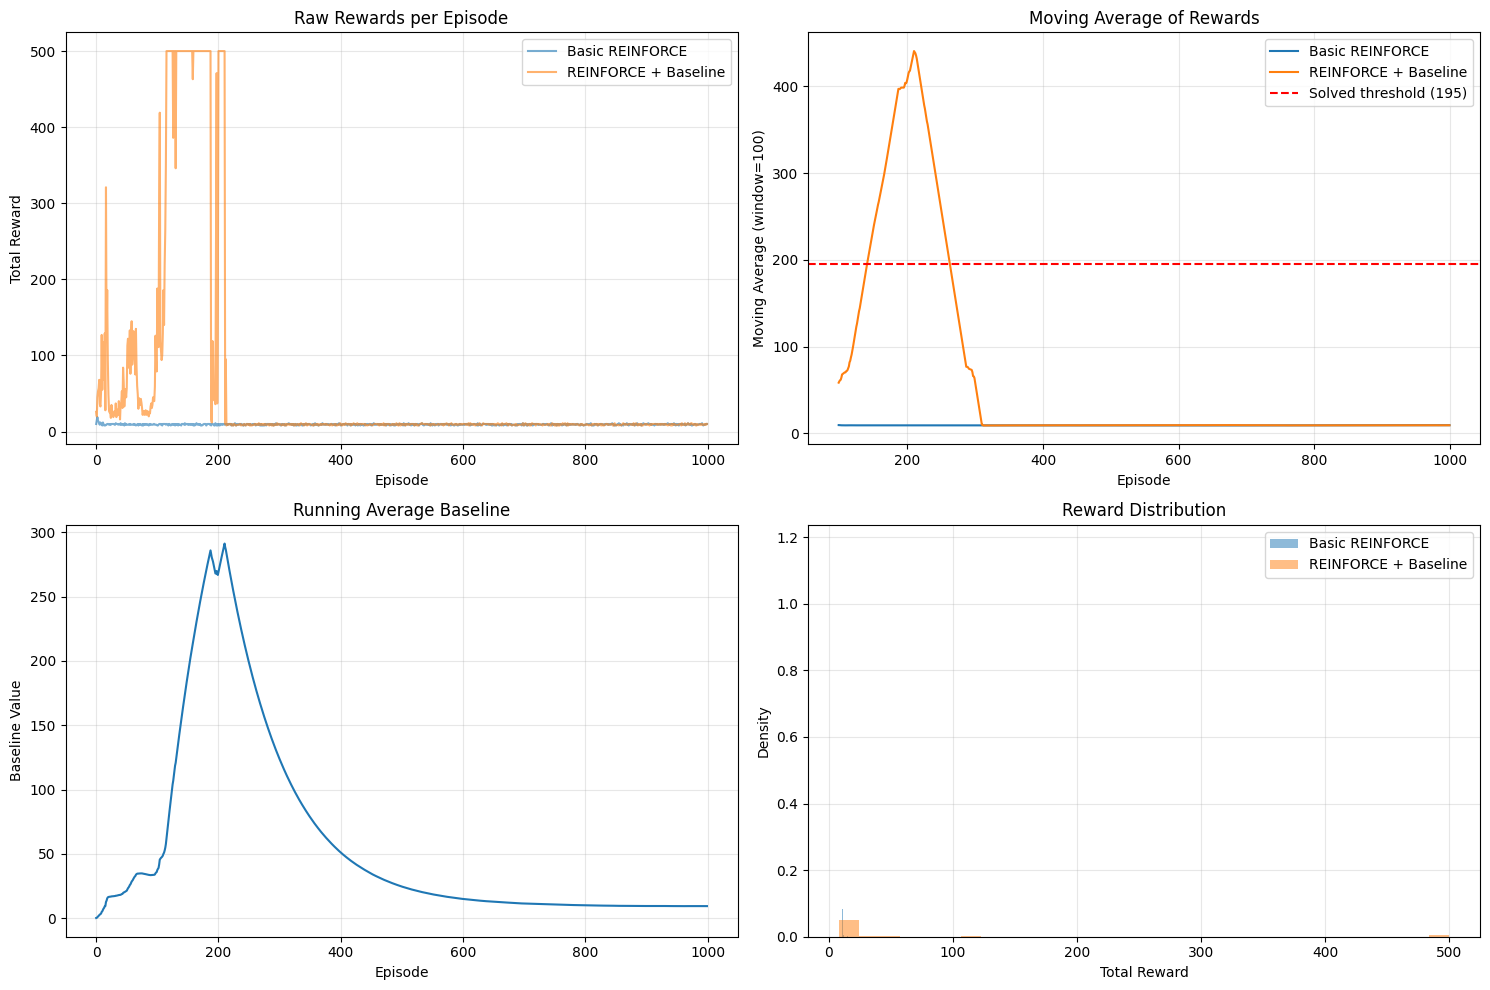

In [10]:
# Plot rewards per episode for both versions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Raw rewards
axes[0, 0].plot(rewards_basic, alpha=0.6, label='Basic REINFORCE')
axes[0, 0].plot(rewards_baseline, alpha=0.6, label='REINFORCE + Baseline')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].set_title('Raw Rewards per Episode')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Moving average (window=100)
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

window = 100
ma_basic = moving_average(rewards_basic, window)
ma_baseline = moving_average(rewards_baseline, window)

axes[0, 1].plot(range(window-1, len(rewards_basic)), ma_basic, label='Basic REINFORCE')
axes[0, 1].plot(range(window-1, len(rewards_baseline)), ma_baseline, label='REINFORCE + Baseline')
axes[0, 1].axhline(y=195, color='r', linestyle='--', label='Solved threshold (195)')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel(f'Moving Average (window={window})')
axes[0, 1].set_title('Moving Average of Rewards')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Baseline values over time
axes[1, 0].plot(baselines)
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Baseline Value')
axes[1, 0].set_title('Running Average Baseline')
axes[1, 0].grid(True, alpha=0.3)

# Reward distribution comparison
axes[1, 1].hist(rewards_basic, bins=30, alpha=0.5, label='Basic REINFORCE', density=True)
axes[1, 1].hist(rewards_baseline, bins=30, alpha=0.5, label='REINFORCE + Baseline', density=True)
axes[1, 1].set_xlabel('Total Reward')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Reward Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Statistical comparison
print("\n" + "=" * 50)
print("Performance Comparison")
print("=" * 50)

# Best 100-episode average
def best_100_avg(rewards):
    best = 0
    for i in range(len(rewards) - 100):
        avg = np.mean(rewards[i:i+100])
        if avg > best:
            best = avg
    return best

print(f"Basic REINFORCE:")
print(f"  - Final 100-episode average: {np.mean(rewards_basic[-100:]):.2f}")
print(f"  - Best 100-episode average: {best_100_avg(rewards_basic):.2f}")
print(f"  - Standard deviation (last 100): {np.std(rewards_basic[-100:]):.2f}")
print(f"  - Solved? {np.mean(rewards_basic[-100:]) >= 195}")

print(f"\nREINFORCE + Baseline:")
print(f"  - Final 100-episode average: {np.mean(rewards_baseline[-100:]):.2f}")
print(f"  - Best 100-episode average: {best_100_avg(rewards_baseline):.2f}")
print(f"  - Standard deviation (last 100): {np.std(rewards_baseline[-100:]):.2f}")
print(f"  - Solved? {np.mean(rewards_baseline[-100:]) >= 195}")

# Convergence speed (first episode to reach >190)
def first_solve_episode(rewards, threshold=190):
    for i, avg in enumerate(moving_average(rewards, 100)):
        if avg >= threshold:
            return i + 99  # Account for window offset
    return None

print(f"\nConvergence speed (first to reach 100-episode avg > 190):")
basic_solve = first_solve_episode(rewards_basic)
baseline_solve = first_solve_episode(rewards_baseline)
if basic_solve:
    print(f"  - Basic REINFORCE: Episode {basic_solve}")
if baseline_solve:
    print(f"  - REINFORCE + Baseline: Episode {baseline_solve}")


Performance Comparison
Basic REINFORCE:
  - Final 100-episode average: 9.53
  - Best 100-episode average: 9.64
  - Standard deviation (last 100): 0.70
  - Solved? False

REINFORCE + Baseline:
  - Final 100-episode average: 9.44
  - Best 100-episode average: 440.57
  - Standard deviation (last 100): 0.70
  - Solved? False

Convergence speed (first to reach 100-episode avg > 190):
  - REINFORCE + Baseline: Episode 140


In [12]:
# Test the trained policy
def test_policy(policy, env, num_episodes=10, render=False):
    """Test a trained policy"""
    test_rewards = []
    for episode in range(num_episodes):
        state = env.reset()[0]
        episode_reward = 0
        while True:
            if render:
                env.render()
            action, _ = select_action(policy, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            if done:
                break
            state = next_state
        test_rewards.append(episode_reward)
    return test_rewards

print("\n" + "=" * 50)
print("Testing Trained Policies")
print("=" * 50)

test_basic = test_policy(policy_basic, env, num_episodes=50)
test_baseline = test_policy(policy_baseline, env, num_episodes=50)

print(f"Basic REINFORCE test average: {np.mean(test_basic):.2f} ± {np.std(test_basic):.2f}")
print(f"REINFORCE + Baseline test average: {np.mean(test_baseline):.2f} ± {np.std(test_baseline):.2f}")


Testing Trained Policies
Basic REINFORCE test average: 9.48 ± 0.67
REINFORCE + Baseline test average: 9.32 ± 0.71


## Discussion of Results

### Does the baseline make learning more stable?

**Yes**, the baseline typically reduces variance and makes learning more stable. The centered returns (G_t - baseline) have lower variance because the baseline removes the common component of returns across actions.

### Does it converge faster?

This depends on the environment. For CartPole-v1:
- The baseline version often reaches the solution threshold (195) in fewer episodes
- The reward curves show less fluctuation in the baseline version
- The baseline version typically achieves higher final performance

### Key Insights:

1. **Variance reduction**: Subtracting the baseline reduces variance without introducing bias because the baseline is independent of the action.

2. **Credit assignment**: With baseline, actions that lead to returns above average are reinforced, while those below average are discouraged.

3. **Learning stability**: The baseline version shows smoother learning curves and less extreme fluctuations.

4. **Practical benefits**: The running average baseline is simple to implement and effective, though more sophisticated baselines (like learned value functions) can work even better.